# On meijering's normalisation

`on_hessian.md` finds a border defect in `hessian_matrix` and proposes fixes A
and C. Applied together they take `frangi`, `sato` and `hessian` to exact
agreement with a once-extended reference. `meijering` does not follow: it drops
from 26.3% to 3.3%, and the residue is its *interior* figure, unchanged.

This notebook is about that residue. It is a second defect, in `meijering`
alone, that the border fix exposes rather than causes — and the obvious repair
makes the filter worse, which is why it is worth a notebook rather than a patch.

Everything here assumes the Hessian is already fixed. Coordinates are in array
order throughout.

In [1]:
import numpy as np
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
import skimage as ski
from skimage.filters import meijering, sato, frangi, hessian
from skimage.feature import hessian_matrix, hessian_matrix_eigvals

In [3]:
# Slots 1 to 3 of the reference categorical palette, validated all-pairs.
C_ONE, C_TWO, C_THREE = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dedcd5"
SEQ = LinearSegmentedColormap.from_list("seq", ["#f7f7f4", C_ONE])

plt.rcParams.update(
    {"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9,
     "axes.titlecolor": MUTED, "figure.facecolor": "white"}
)


def bare(ax, title=None):
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title:
        ax.set_title(title)
    return ax


def recede(ax, title=None):
    ax.tick_params(labelsize=8, colors=MUTED)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRID)
    if title:
        ax.set_title(title)
    return ax


PHOTO = ski.util.img_as_float(ski.data.camera())[::2, ::2]
SIGMAS = (1, 3, 5)
RIDGE = dict(sigmas=SIGMAS, mode="nearest")

## 1. One line, and only in `meijering`

`filters/ridges.py` holds four ridge filters that share a shape: sweep `sigmas`,
build the Hessian at each, reduce its eigenvalues to a score, and keep the
pixel-wise maximum across scales. Three of them do exactly that. `meijering`
inserts one more step, at `ridges.py:96`:

```python
vals = np.maximum(vals, 0)
# Normalize to max = 1 (unless everything is already zero).
max_val = vals.max()
if max_val > 0:
    vals /= max_val
filtered_max = np.maximum(filtered_max, vals)
```

Each scale is divided by **its own maximum over the whole image** before the
cross-scale maximum is taken. That is the only per-scale normalisation in the
module: `sato`, `frangi` and `hessian` have nothing like it.

The consequence is that the value at a pixel stops depending only on the
neighbourhood of that pixel.

In [4]:
def far_field_change(f, image, spot=(0, 0), value=10.0, keep=100):
    """How much the response changes far away when one distant pixel changes."""
    edited = image.copy()
    edited[spot] = value
    before, after = f(image, **RIDGE), f(edited, **RIDGE)
    far = (slice(keep, None), slice(keep, None))
    return (np.abs(before[far] - after[far]).max()
            / max(np.abs(before[far]).max(), 1e-12))


print("one pixel brightened at (0, 0); change measured 100 px away")
for name, f in (("meijering", meijering), ("sato", sato), ("frangi", frangi)):
    print(f"   {name:<10}{far_field_change(f, PHOTO):>10.2%}")

one pixel brightened at (0, 0); change measured 100 px away


   meijering     86.90%


   sato           0.00%


   frangi        96.46%


`sato` is unaffected, as a local filter should be. `meijering` moves by 87%.

`frangi` moves too, and for a different reason worth naming so it is not
mistaken for this one. Its `gamma` defaults to `s.max() / 2`, half the largest
Hessian norm in the whole image. That is also a global statistic, but the
`if gamma is None` test sits *inside* the σ loop, so the value is computed on
the first σ only and then frozen for the rest — one number, reused at every
scale, rather than a fresh one per scale.

That keeps `frangi` out of the argument here only by degree, not in kind.
`on_frangi.md` measures both: one frozen γ moves the winning scale at about 6%
of pixels on `camera`, where a per-scale divisor moves it at about 43%. And
freezing it at the *first* σ gives `frangi` a defect `meijering` does not have
— its answer depends on the order of the `sigmas` list. That notebook proposes
the fix. The rest of this one is about `meijering`.

The cleaner probe is cropping, because it changes the image's extent without
touching any shared pixel.

In [5]:
def crop_change(f, image, size=120, margin=20):
    """Same pixels, smaller surroundings: how much does the shared interior move?"""
    whole = f(image, **RIDGE)[:size, :size]
    part = f(image[:size, :size], **RIDGE)
    inner = (slice(margin, -margin),) * 2
    return (np.abs(whole[inner] - part[inner]).max()
            / max(np.abs(whole[inner]).max(), 1e-12))


print("crop to 120x120; change in the shared interior, away from the new border")
for name, f in (("meijering", meijering), ("sato", sato), ("frangi", frangi)):
    print(f"   {name:<10}{crop_change(f, PHOTO):>10.2%}")

crop to 120x120; change in the shared interior, away from the new border
   meijering     15.74%


   sato           0.04%
   frangi         0.00%


Only `meijering` moves. That is the 3.3% residue of `on_hessian.md` section 9,
seen without a Hessian anywhere in the argument: a once-extended reference is a
larger image, and a larger image has a different maximum.

## 2. Why the line is there

Delete it and the filter gets worse, which is the reason this is a notebook and
not a one-line patch.

A reimplementation with the normalisation switchable makes the comparison
possible. It reproduces the shipped filter when asked to.

In [6]:
from scipy import linalg


def meijering_core(image, sigmas, how="maxnorm", alpha=None, black_ridges=True,
                   mode="nearest"):
    """`meijering`, transcribed, with the per-scale normalisation switchable.

    how = "maxnorm"    divide each scale by its own global maximum, as shipped
          "none"       no per-scale normalisation
          "gamma"      multiply by sigma**2 (Lindeberg γ = 1)
          "lindeberg"  multiply by sigma**1.5 (Lindeberg γ = 3/4 for ridges)
    """
    image = image.astype(float, copy=False)
    if not black_ridges:                        # as shipped: negate the image,
        image = -image                          # not the response
    if alpha is None:
        alpha = 1 / (image.ndim + 1)
    mtx = linalg.circulant([1, *[alpha] * (image.ndim - 1)]).astype(image.dtype)

    out = np.zeros_like(image)
    per_scale = {}
    for sigma in sigmas:
        eigs = hessian_matrix_eigvals(
            hessian_matrix(image, sigma, mode=mode, use_gaussian_derivatives=True))
        vals = np.tensordot(mtx, eigs, 1)
        vals = np.take_along_axis(vals, abs(vals).argmax(0)[None], 0).squeeze(0)
        vals = np.maximum(vals, 0)
        if how == "maxnorm":
            peak = vals.max()
            if peak > 0:
                vals = vals / peak
        elif how == "gamma":
            vals = vals * sigma**2
        elif how == "lindeberg":
            vals = vals * sigma**1.5
        per_scale[sigma] = vals
        out = np.maximum(out, vals)
    return out, per_scale


for black in (True, False):
    mine, _ = meijering_core(PHOTO, SIGMAS, black_ridges=black)
    theirs = meijering(PHOTO, black_ridges=black, **RIDGE)
    print(f"reimplementation vs shipped, black_ridges={black}: "
          f"max |difference| {np.abs(mine - theirs).max():.2e}")

reimplementation vs shipped, black_ridges=True: max |difference| 0.00e+00


reimplementation vs shipped, black_ridges=False: max |difference| 0.00e+00


Now a test image with two ridges of very different width, far enough apart not
to interact.

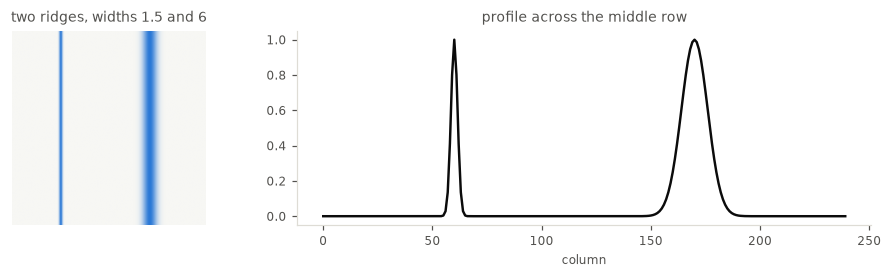

In [7]:
N = 240
rows, cols = np.indices((N, N), dtype=float)
NARROW, WIDE = 1.5, 6.0
ridges = (np.exp(-((cols - 60) ** 2) / (2 * NARROW**2))
          + np.exp(-((cols - 170) ** 2) / (2 * WIDE**2)))
SCAN = (1, 2, 3, 4, 6, 8)

fig, axes = plt.subplots(1, 2, figsize=(8.6, 2.6),
                         gridspec_kw={"width_ratios": [1, 2]})
bare(axes[0], "two ridges, widths 1.5 and 6")
axes[0].imshow(ridges, cmap=SEQ)
axes[1].plot(ridges[N // 2], color=INK, lw=1.6)
recede(axes[1], "profile across the middle row")
axes[1].set_xlabel("column", fontsize=8, color=MUTED)
fig.tight_layout()

A multiscale ridge filter has one job on this image beyond finding the ridges:
report both of them, and report each most strongly at the scale that matches
it. That is what the sweep over `sigmas` is *for*.

In [8]:
print(f"{'variant':<10}{'sigma winning at':>20}{'':>8}{'peak response':>22}")
print(f"{'':<10}{'narrow':>12}{'wide':>8}{'':>8}{'narrow':>11}{'wide':>11}")
for how in ("maxnorm", "none", "gamma"):
    out, per_scale = meijering_core(ridges, SCAN, how=how,
                                    black_ridges=False)
    pick = lambda col: max(SCAN, key=lambda s: per_scale[s][N // 2, col])
    narrow_peak = out[N // 2, 50:70].max()
    wide_peak = out[N // 2, 160:180].max()
    print(f"{how:<10}{pick(60):>12}{pick(170):>8}{'':>8}"
          f"{narrow_peak:>11.4f}{wide_peak:>11.4f}")

variant       sigma winning at                 peak response
                narrow    wide             narrow       wide
maxnorm              1       6             1.0000     1.0000


none                 1       1             0.2522     0.0265
gamma                2       8             0.3840     0.3840


Deleting the line is the "none" row, and it fails the job. Scale 1 wins at both
ridges, and the wide ridge comes back ten times weaker than the narrow one,
because raw Hessian eigenvalues shrink as `sigma` grows: a second derivative of
a smoothed image carries a factor that falls off with scale, so without
compensation the smallest scale always wins.

So the division is not decoration. It is **scale normalisation**, done by an
empirical statistic. It puts every scale on a common footing, which is exactly
what makes the cross-scale maximum meaningful.

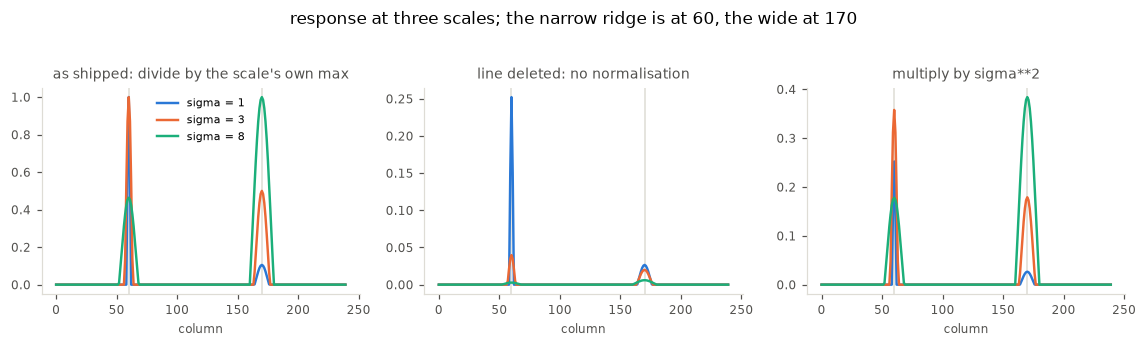

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0), sharey=False)
for ax, how, title in zip(axes, ("maxnorm", "none", "gamma"),
                          ("as shipped: divide by the scale's own max",
                           "line deleted: no normalisation",
                           "multiply by sigma**2")):
    _, per_scale = meijering_core(ridges, SCAN, how=how,
                                  black_ridges=False)
    for sigma, colour in zip((1, 3, 8), (C_ONE, C_TWO, C_THREE)):
        ax.plot(per_scale[sigma][N // 2], color=colour, lw=1.6,
                label=f"sigma = {sigma}")
    for centre in (60, 170):
        ax.axvline(centre, color=GRID, lw=1, zorder=0)
    recede(ax, title)
    ax.set_xlabel("column", fontsize=8, color=MUTED)
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle("response at three scales; the narrow ridge is at 60, the wide at 170",
             y=1.03)
fig.tight_layout()

The middle panel is the argument against the naive fix, drawn: with no
normalisation, `sigma = 1` towers over the others everywhere and the wide ridge
barely registers. The left and right panels both put the scales on comparable
footing; they differ in what they use to do it.

## 3. The principled version of the same idea

Scale normalisation is a solved problem, and the solution predates the filter.
Lindeberg's γ-normalised derivative multiplies a derivative of order `n` by
`sigma**(n * gamma)`; for a second derivative with `gamma = 1` that is
`sigma**2`. It compensates for exactly the falloff the middle panel shows, and
it does so from `sigma` alone — no image statistic, so nothing outside the
neighbourhood enters. (For ridge detection the preferred γ is not 1; §5.)

Measured, it does the job the empirical version does:

In [10]:
print("does the filter stay local?")
print(f"{'variant':<10}{'one distant pixel':>20}{'crop':>10}")
for how in ("maxnorm", "gamma"):
    variant = (lambda im, _how=how, **kw: meijering_core(im, SIGMAS, how=_how)[0])
    print(f"{how:<10}{far_field_change(variant, PHOTO):>20.2%}"
          f"{crop_change(variant, PHOTO):>10.2%}")

does the filter stay local?
variant      one distant pixel      crop


maxnorm                 86.90%    15.74%


gamma                    0.00%     0.03%


`gamma` is local by construction: the same pixels give the same answer whatever
surrounds them. It is not bit-exact under cropping — 0.03% remains, from the
Hessian's own boundary handling at the new edge — but that is three orders of
magnitude below the 16% the empirical version shows, and it is a border effect
rather than a global one.

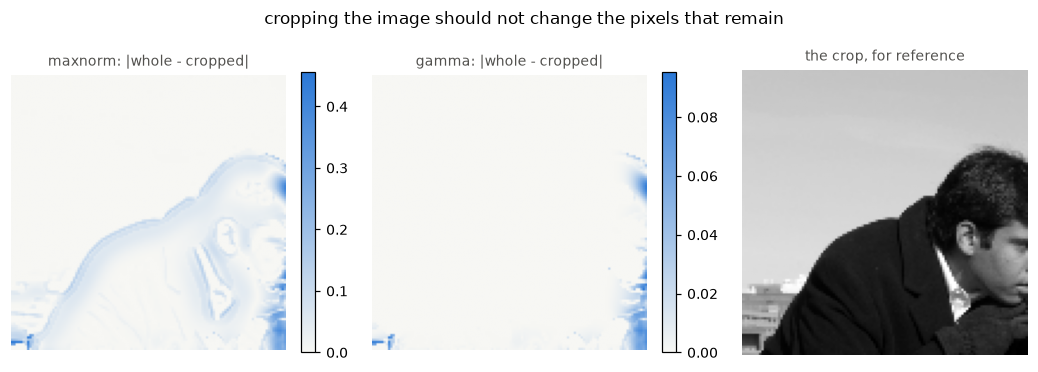

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2))
whole = {how: meijering_core(PHOTO, SIGMAS, how=how)[0]
         for how in ("maxnorm", "gamma")}
part = {how: meijering_core(PHOTO[:120, :120], SIGMAS, how=how)[0]
        for how in ("maxnorm", "gamma")}
for ax, how in zip(axes[:2], ("maxnorm", "gamma")):
    gap = np.abs(whole[how][:120, :120] - part[how])
    im = ax.imshow(gap, cmap=SEQ)
    bare(ax, f"{how}: |whole - cropped|")
    fig.colorbar(im, ax=ax, fraction=0.046)
bare(axes[2], "the crop, for reference")
axes[2].imshow(PHOTO[:120, :120], cmap="gray")
fig.suptitle("cropping the image should not change the pixels that remain", y=1.02)
fig.tight_layout()

## 4. Why this is not simply a patch

The obvious conclusion — replace the division with `sigma**2` — is the change
that was already made, questioned, and reversed. The history is worth knowing
before proposing it again.

[#5561, "Meijering scaling issue"](https://github.com/scikit-image/scikit-image/issues/5561),
reported that the implementation of the day applied a `sigma**2` scaling to the
Hessian eigenvalues that the reporter could not reconcile with the paper's
appendix: "this would be correct if the Hessian matrix missed a factor
`sigma**2` also, but I cannot find such a source of error". The filters were
then rewritten in
[#6446](https://github.com/scikit-image/scikit-image/issues/6446), and the
version in the tree today divides by the per-scale maximum instead.

So the two candidates have each been shipped, and each has an objection on the
record:

| | scale normalisation | objection |
| --- | --- | --- |
| before #6446 | `* sigma**2` | not derivable from the paper, per #5561 |
| today | `/ vals.max()` | not local; the value at a pixel depends on the whole image |

The objections are not of the same kind, which is the useful observation. The
first is about whether a particular constant matches a particular paper — a
question with an answer in the appendix of
[Meijering et al. (2004)](https://doi.org/10.1002/cyto.a.20022). The second is
about a property no ridge filter should lack, and it can be demonstrated
without reading anything.

The appendix settles the first question, and splits it. Detection is
**single-scale**: one Gaussian width σ, "tuned to neurites of specific width"
(their Table 1 uses σ = 2.0). Derivatives are `f * G_ij` with no `σ²` factor on
the Hessian. Neuriteness is then

$$
\rho(x) =
\begin{cases}
\lambda(x)/\lambda_{\min} & \text{if }\lambda(x) < 0, \\
0 & \text{otherwise,}
\end{cases}
$$

where λ is the larger-magnitude eigenvalue of the modified Hessian and
λ_min is the most negative λ **over the whole image**. So global
normalisation *is* in the paper: it maps ρ into a [0, 1] "probability" for the
live-wire cost. It is **not** Lindeberg γ-normalisation, and there is no
cross-scale maximum. Today's `/vals.max()` is the natural multiscale extension
of ρ; the multiscale fusion itself is a skimage addition the paper never
defines.

A third possibility stays on the table for that fusion: the γ for ridge
detection is not obviously 1. Lindeberg's ridge scale-selection work argues
for `gamma = 3/4`, which makes the factor `sigma**1.5` rather than `sigma**2`.
#5561 was right that `sigma**2` is not in the paper; that does not make
per-scale `/max` the right tool for comparing scales.

In [12]:
print("which sigma wins at each ridge, for a few exponents")
print(f"{'factor':>12}{'narrow (true 1.5)':>20}{'wide (true 6.0)':>18}")
for power in (0.0, 1.0, 1.5, 2.0, 2.5):
    _, per_scale = meijering_core(ridges, SCAN, how="none",
                                  black_ridges=False)
    scaled = {s: v * s**power for s, v in per_scale.items()}
    pick = lambda col: max(SCAN, key=lambda s: scaled[s][N // 2, col])
    print(f"{'sigma**' + str(power):>12}{pick(60):>20}{pick(170):>18}")

which sigma wins at each ridge, for a few exponents
      factor   narrow (true 1.5)   wide (true 6.0)
  sigma**0.0                   1                 1


  sigma**1.0                   1                 4
  sigma**1.5                   2                 6


  sigma**2.0                   2                 8
  sigma**2.5                   3                 8


The exponent is not a free choice that only affects magnitudes: it decides which
scale is reported for a given feature, so it decides the filter's answer.

On this pair of ridges, `sigma**1.5` — Lindeberg's `gamma = 3/4` for ridge
detection — reports 2 and 6 for ridges of width 1.5 and 6.0, where `sigma**2`
overshoots the wide one at 8. The wide ridge is the informative column: on an
integer grid 2 is no closer to 1.5 than 1 is, so the narrow one is a tie and
proves nothing. §6.2 repeats the scan on widths that sit on the grid, and
§5.1 repeats it on a grid fine enough to read the peak position off directly.
The next section derives the exponent from the source paper and places it
against other ridge filters.

## 5. Lindeberg's γ = 3/4

The reference is
[Lindeberg, *Int. J. Comput. Vis.* 30(2):117–154, 1998](https://doi.org/10.1023/A:1008097225773)
("Edge detection and ridge detection with automatic scale selection";
[author PDF](https://people.kth.se/~tony/papers/cvap191.pdf)). A short CVPR'96
version states the same ridge result. Meijering et al. cite Lindeberg's
*Scale-Space Theory in Computer Vision* (1994) for the Gaussian scale-space
setting, but they do **not** use this γ-normalisation, and they do not run a
multiscale max.

### 5.1 The cylindrical Gaussian ridge

Lindeberg works in the diffusion scale parameter $t = \sigma^2$. A
γ-normalised spatial derivative of order $n$ is $t^{n\gamma/2}$ times the
ordinary derivative; for a second derivative that is a factor $t^\gamma$.
Section 5.6.1 takes a cylindrical ridge whose cross-section is a 1-D Gaussian
of variance $t_0$:

$$
f(x, y) = g(x; t_0), \qquad
L(x, y; t) = g(x; t_0 + t).
$$

On the ridge axis the γ-normalised principal-curvature strength is

$$
M_{\gamma\text{-norm}} L(0, y; t)
  = t^\gamma \bigl|g_{xx}(0; t_0 + t)\bigr|
  \propto \frac{t^\gamma}{(t_0 + t)^{3/2}}.
$$

Maximising with respect to $t$ gives a unique peak (for $0 < \gamma < 3/2$) at

$$
t^\ast = \frac{2\gamma}{3 - 2\gamma}\, t_0.
$$

Two calibrations follow at once:

| choice | selected $t^\ast$ | meaning |
| --- | --- | --- |
| $\gamma = 1$ | $2\,t_0$ | classical scale-normalised second derivative; peak at $\sigma^\ast = w\sqrt{2}$ |
| $\gamma = 3/4$ | $t_0$ | peak at the ridge's own width, $\sigma^\ast = w$ |

γ = 3/4 is therefore not an empirical fit. It is the unique value that makes
this strength measure select the model ridge's own variance. The same
$t^\ast$ formula appears for his other ridge strengths $N$ and $A$ on this
model. In σ-units the multiplier on a raw second-derivative response is
$\sigma^{2\gamma}$, so γ = 3/4 → `sigma**1.5` and γ = 1 → `sigma**2`.

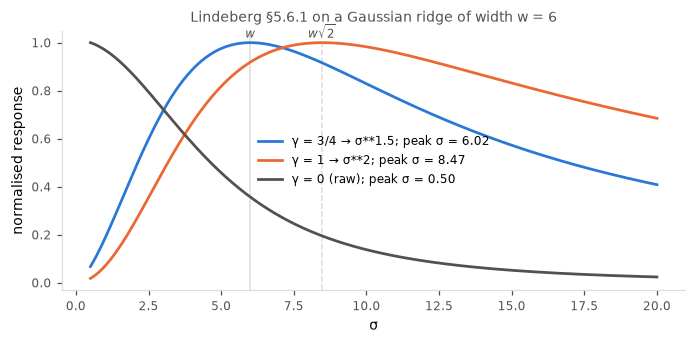

In [13]:
# Continuous ridge model: response ∝ sigma**(2γ) / (w² + sigma²)**1.5
w = 6.0
sigmas = np.linspace(0.5, 20, 400)
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for gamma, colour, label in (
        (0.75, C_ONE, r"γ = 3/4 → σ**1.5"),
        (1.0, C_TWO, r"γ = 1 → σ**2"),
        (0.0, MUTED, r"γ = 0 (raw)")):
    resp = sigmas**(2 * gamma) / (w**2 + sigmas**2)**1.5
    resp /= resp.max()
    peak = sigmas[np.argmax(resp)]
    ax.plot(sigmas, resp, color=colour, lw=1.8, label=f"{label}; peak σ = {peak:.2f}")
ax.axvline(w, color=GRID, lw=1, zorder=0)
ax.axvline(w * np.sqrt(2), color=GRID, lw=1, ls="--", zorder=0)
ax.text(w, 1.02, r"$w$", ha="center", color=MUTED, fontsize=8)
ax.text(w * np.sqrt(2), 1.02, r"$w\sqrt{2}$", ha="center", color=MUTED, fontsize=8)
recede(ax, f"Lindeberg §5.6.1 on a Gaussian ridge of width w = {w:g}")
ax.set_xlabel("σ")
ax.set_ylabel("normalised response")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

### 5.2 The same statement, measured on the filter

Section 5.1 is a continuous model. Three things could go wrong between it and
the shipped filter, and each is cheap to check.

**The Hessian this notebook consumes is the broken one.** Every scan here calls
`hessian_matrix` as shipped, which `on_hessian.md` shows is inaccurate at small
σ — and small σ is exactly where γ = 3/4 and γ = 1 are told apart. So repeat
the scan on a Hessian built with fixes A and C: one pass per element, with taps
whose discrete moments are repaired.

In [14]:
def gaussian_taps(sigma, order, trunc=8):
    """The 1-D kernel `gaussian_filter` builds, from the explicit formula."""
    lw = int(trunc * sigma + 0.5)
    x = np.arange(-lw, lw + 1).astype(float)
    g = np.exp(-(x**2) / (2 * sigma**2))
    g /= g.sum()
    if order == 0:
        return x, g
    if order == 1:
        return x, g * (x / sigma**2)
    return x, g * ((x**2 - sigma**2) / sigma**4)


def corrected_taps(sigma, order):
    """Fix C of `on_hessian.md`: repair the discrete moments."""
    x, g = gaussian_taps(sigma, 0)
    _, k = gaussian_taps(sigma, order)
    if order == 0:
        return x, g
    if order == 1:
        return x, k / (k * x).sum()             # exact on f = x
    k = k - k.sum() * g                         # annihilate constants
    return x, k / ((k * x**2).sum() / 2)        # exact on f = x**2 / 2


def fixed_eigvals(image, sigma, mode="nearest"):
    """Fix A + fix C, then the 2x2 eigenvalues, largest first."""
    def apply(orders):                          # fix A: one pass per element
        out = image
        for axis, order in enumerate(orders):
            out = ndi.correlate1d(out, corrected_taps(sigma, order)[1],
                                  axis=axis, mode=mode)
        return out

    hrr, hrc, hcc = (apply(o) for o in ((2, 0), (1, 1), (0, 2)))
    total = hrr + hcc
    spread = np.sqrt((hrr - hcc) ** 2 + 4 * hrc**2)
    return np.stack([(total + spread) / 2, (total - spread) / 2])

In [15]:
TWO = (np.exp(-((cols - 60) ** 2) / (2 * 2.0**2))
       + np.exp(-((cols - 170) ** 2) / (2 * 6.0**2)))
GRID_COARSE = (1, 2, 3, 4, 5, 6, 7, 8)


def winners(image, sigmas, power, fixed, alpha=1 / 3, at=(60, 170)):
    """Which sigma maximises the neuriteness at each ridge centre."""
    row, best = image.shape[0] // 2, []
    scored = {}
    for sigma in sigmas:
        eig = (fixed_eigvals(-image, sigma) if fixed
               else hessian_matrix_eigvals(hessian_matrix(
                   -image, sigma, mode="nearest",
                   use_gaussian_derivatives=True)))
        vals = np.stack([eig[0] + alpha * eig[1], eig[1] + alpha * eig[0]])
        v = np.take_along_axis(vals, abs(vals).argmax(0)[None], 0).squeeze(0)
        scored[sigma] = np.maximum(v, 0) * sigma**power
    for col in at:
        best.append(max(sigmas, key=lambda s: scored[s][row, col]))
    return tuple(best)


print("winning sigma at each ridge centre  (true widths 2.0 and 6.0)")
print(f"{'factor':<14}{'shipped Hessian':>20}{'fixed A+C':>14}")
for power, label in ((0.0, "none"), (1.5, "sigma**1.5"), (2.0, "sigma**2")):
    print(f"{label:<14}"
          f"{str(winners(TWO, GRID_COARSE, power, False)):>20}"
          f"{str(winners(TWO, GRID_COARSE, power, True)):>14}")

winning sigma at each ridge centre  (true widths 2.0 and 6.0)
factor             shipped Hessian     fixed A+C


none                        (1, 1)        (1, 1)


sigma**1.5                  (2, 6)        (2, 6)


sigma**2                    (3, 8)        (3, 8)


The Hessian fix changes nothing about which σ wins. That matters because the
introduction says this notebook assumes the Hessian is already repaired, and
the code does not repair it; now the claim is checked rather than asserted.

**A coarse integer grid hides where the peak really is.** Refine it, and the
discrete filter reproduces section 5.1's arithmetic directly.

In [16]:
FINE = np.round(np.arange(1.0, 10.01, 0.25), 2)

print("peak of the scan, on a 0.25 grid, fixed Hessian")
print(f"{'factor':<14}{'narrow (w = 2)':>16}{'wide (w = 6)':>14}"
      f"{'  predicted by 5.6.1':>22}")
for power, gamma in ((1.5, 0.75), (2.0, 1.0)):
    narrow, wide = winners(TWO, FINE, power, True)
    ratio = np.sqrt(2 * gamma / (3 - 2 * gamma))     # sigma* / w
    print(f"{'sigma**' + str(power):<14}{narrow:>16}{wide:>14}"
          f"{f'  {2 * ratio:.2f}, {6 * ratio:.2f}':>22}")

peak of the scan, on a 0.25 grid, fixed Hessian
factor          narrow (w = 2)  wide (w = 6)    predicted by 5.6.1


sigma**1.5                 2.0           6.0            2.00, 6.00


sigma**2.0                2.75           8.5            2.83, 8.49


`sigma**1.5` lands on the true widths; `sigma**2` lands on $w\sqrt2$ for both,
to within the quarter-pixel grid. The continuous derivation survives
discretisation, the modified Hessian, the α reshaping and the clip at zero.

**The α sign does not change any of this — but it costs something else.**
Section 7 asks for α = −1/(ndim+1), and every scan above ran with the shipped
`+1/(ndim+1)`. For a straight ridge one principal curvature is zero, so
λ′ = λ₁ + αλ₂ = λ₁ whatever α is, and the exponent argument is untouched. What
α buys is the paper's flatness criterion, and that is about the structures
which are *not* ridges.

In [17]:
blob = np.exp(-((rows - N // 2) ** 2 + (cols - N // 2) ** 2) / (2 * 4.0**2))
one_ridge = np.exp(-((cols - 60) ** 2) / (2 * 4.0**2))
mixed = blob + one_ridge

print(f"{'alpha':<18}{'blob':>10}{'ridge':>10}{'blob/ridge':>14}")
for alpha, label in ((1 / 3, "+1/3 (shipped)"), (-1 / 3, "-1/3 (paper)")):
    out, _ = meijering_core(mixed, (4,), how="none", alpha=alpha,
                            black_ridges=False)
    b, r = out[N // 2, N // 2], out[N // 2, 60]
    print(f"{label:<18}{b:>10.4f}{r:>10.4f}{b / r:>14.3f}")

alpha                   blob     ridge    blob/ridge
+1/3 (shipped)        0.0208    0.0221         0.943
-1/3 (paper)          0.0104    0.0221         0.471


The paper's sign halves the blob relative to the ridge; the shipped sign leaves
the two almost equal. The appendix derives α from

$$
\lim_{x\to0}(r_\perp\!\cdot\!\nabla)^2 h'(x)
  = (1 + 3\alpha)\,\|r\|^4/\sigma^4 = 0,
$$

which is exactly the condition that the filter be flat along the ridge, and so
not fire on isotropic structure. Lindeberg's §5.6.2 says the plain
principal-curvature measure $M_{\gamma\text{-norm}}$ "give[s] strong responses
at edges" and "comparably strong blob responses"; the α reshaping is
Meijering's answer to that, and with the sign reversed it is closer to an
amplifier than a suppressor.

One detail the paper leaves in 2-D and skimage generalises: the constant 3 in
$(1 + 3\alpha)$ is the fourth moment of the 1-D Gaussian — the ratio of the
fourth derivative of $g$ at the origin to $g(0)$ is $3/\sigma^4$ — and not the
dimension. Carrying the same limit through in $n$ dimensions gives
$1 + (n+1)\alpha = 0$, so the docstring's −1/(ndim+1) is the right
generalisation, and only the sign in the code is wrong.

In [18]:
def flatness_alpha(ndim, sigma=1.7):
    """Solve (d/dy)^2 [G_xx + a * sum_perp G_kk] = 0 at the origin."""
    a0 = 1 / np.sqrt(2 * np.pi * sigma**2)          # g(0)
    a2 = -a0 / sigma**2                             # g''(0)
    a4 = 3 * a0 / sigma**4                          # g''''(0)
    const = a2 * a2 * a0 ** (ndim - 2)              # G_xxyy(0)
    coeff = a4 * a0 ** (ndim - 1) + (ndim - 2) * const
    return -const / coeff


for ndim in (2, 3, 4):
    print(f"ndim {ndim}: flatness alpha {flatness_alpha(ndim):+.6f}"
          f"   -1/(ndim+1) {-1 / (ndim + 1):+.6f}")

ndim 2: flatness alpha -0.333333   -1/(ndim+1) -0.333333
ndim 3: flatness alpha -0.250000   -1/(ndim+1) -0.250000
ndim 4: flatness alpha -0.200000   -1/(ndim+1) -0.200000


### 5.3 Why this matters for `meijering`

Meijering's score at a pixel is (up to the α reshaping and the global ρ map)
the larger-magnitude Hessian eigenvalue — the same principal curvature that
enters $M_{\gamma\text{-norm}}$. Skimage's API then takes the pixel-wise
maximum of that score over a list of σ. That is a discrete, filter-style
cousin of Lindeberg's "maximise normalised ridge strength over scale", not
something the 2004 neurite paper defines.

So the γ choice answers a question skimage asks and Meijering does not: *when
two scales both fire at a pixel, which one should win?* Without a local
σ-power, the smallest σ always wins (middle panel of §2). With γ = 1 the
continuous model systematically prefers σ larger than the ridge width; with
γ = 3/4 it prefers the width. The discrete scan in §4 is the same statement
on the filter as shipped.

The paper's ρ = λ/λ_min remains available **after** fusion if a [0, 1]
display or cost map is wanted. That is a global affine rescale of the fused
result; it does not choose the winning scale.

### 5.4 Who else applies this result

I found no paper that takes Meijering's neuriteness formula and replaces its
normalisation with Lindeberg γ = 3/4. The join is therefore an argument about
skimage's multiscale extension, not a reconstruction of published Meijering
code. Closely related uses of the same result do exist:

- **Majer (2004)**, ["On the Influence of Scale Selection on Feature Detection
  for the Case of Linelike Structures"](https://doi.org/10.1023/B:VISI.0000036834.42685.b6),
  IJCV 60(3):191–202 — studies Lindeberg's γ for second-derivative line
  filters; recalls γ = 3/4 as the preferred-scale calibration and γ = 3/2 as
  the critical value above which ridges lose a finite-scale maximum. Argues
  that γ also selects *which* structures (ridge vs edge) can be detected.
  Does not discuss Meijering.
- **Vessel / medical ridge work** that Majer surveys (Koller et al. 1995;
  Lorenz et al. 1997) already chose γ so that the selected scale matches a
  model vessel width — the same calibration principle Lindeberg formalises.
- **Sofka & Stewart (2006)**, ["Retinal Vessel Centerline Extraction Using
  Multiscale Matched Filters, Confidence and Edge
  Measures"](https://doi.org/10.1109/TMI.2006.884190), IEEE TMI
  25(12):1531–1546 — build a **γ-normalised matched filter** in scale space,
  citing Lindeberg for the reason output amplitude falls with scale. This is
  the nearest published use of γ-normalisation in the vessel literature. I
  have not been able to confirm from the abstract and secondary sources which
  γ they settle on, so do not cite this one *for* 3/4 without reading it.
- **skimage's other ridge filters.** `sato` multiplies its tubeness product by
  `sigma**2` (γ = 1), and its code comment cites Sato eqs. (9) and (22) for
  that factor, so there it is paper-specified rather than invented. `frangi`
  as rewritten in #6446 takes a max over scales of a bounded vesselness
  without any Lindeberg factor; issue #7711 reports that the missing scale
  correction makes the smallest σ dominate — the same failure mode as
  `meijering` with `how="none"`. Neither filter cites γ = 3/4.
- **`skimage.feature.blob_log`, in this repository**, is the reason `sigma**2`
  feels like the obvious choice. It normalises with
  `-gaussian_laplace(image, s) * mean(s)**2`, that is γ = 1, and for its own
  problem that is exactly right: on a 2-D Gaussian blob the γ-normalised
  Laplacian goes as $t^\gamma/(t_0+t)^2$, which peaks at
  $t^\ast = \gamma t_0/(2-\gamma)$, so γ = 1 selects $t_0$ itself. The same
  γ that lands on the blob's own variance overshoots a ridge's by a factor of
  two in $t$ — $\sqrt 2$ in σ. Blobs and ridges need different exponents
  because the response decays as $(t_0+t)^{-2}$ for one and $(t_0+t)^{-3/2}$
  for the other. §5.1 measures both.
- **DIPlib** ships
  [`FrangiVesselness`](https://diplib.org/diplib-docs/detection_lines.html)
  and documents the multiscale recipe this notebook recommends, with the same
  caveat about provenance: *"Even though the original paper didn't mention
  this, best results are obtained when scaling the input image with the square
  of the sigma"*, then taking the supremum over scales. That is local
  γ = 1 normalisation followed by a max, with no per-scale image statistic
  anywhere. A peer library has already made the choice #6436 left open, and
  said out loud that it is not in the paper.
- **ITK** normalises across scale on the Hessian, not on the measure:
  `MultiScaleHessianBasedMeasureImageFilter` calls
  `m_HessianFilter->SetNormalizeAcrossScale(true)`, which is Lindeberg's
  $\sigma^{n}$ factor for an order-$n$ derivative — γ = 1 — and then keeps the
  best response over exponentially spaced scales. Its
  `HessianToObjectnessMeasureImageFilter` has a separate
  `ScaleObjectnessMeasure` flag, which is *not* a σ power: the line is
  `objectnessMeasure *= sortedAbsEigenValues[ImageDimension - 1]`, a
  multiplication by the largest absolute eigenvalue.
- **OpenCV** has a ridge filter, in contrib:
  `cv::ximgproc::RidgeDetectionFilter` builds a Hessian from Sobel operators
  and returns its larger eigenvalue at one fixed `ksize`. There is no σ loop,
  so the normalisation question never arises. **Pillow** has no ridge filter.

The Wikipedia *Ridge detection* page restates Lindeberg's calibration
(γ = 3/4 so that detection scale equals ridge width; γ = 1 doubles it) and
notes blood-vessel and road extraction as applications of
$L_{pp,\gamma\text{-norm}}$ — again adjacent to Meijering, not a citation of
it.

### 5.5 Scale defaults in scikit-image issues and PRs

No scikit-image issue or PR discusses Lindeberg γ, γ = 3/4, or
`sigma**1.5` for `meijering`. The scale-space discussion that *does* exist is
about σ² versus paper fidelity and about whether multiscale max is justified:

| item | what it says about scale |
| --- | --- |
| [#5561](https://github.com/scikit-image/scikit-image/issues/5561) | σ² on Hessian eigenvalues is not in the paper; with several σ it "unduly" prefers large σ. Also flags Gaussian derivatives and α sign. |
| [#5571](https://github.com/scikit-image/scikit-image/pull/5571) / [#6149](https://github.com/scikit-image/scikit-image/pull/6149) | Meijering switches to `use_gaussian_derivatives=True` (no σ² on that path). #6149 also sets the signature default to **`alpha=-1/3`**, the paper's value. |
| [#6436](https://github.com/scikit-image/scikit-image/issues/6436) (anntzer) | Paper formula is single-σ ρ = λ′/max(−λ′). Explicitly: the article "does not discuss whether maximizing over values obtained for various σ makes sense, **or whether they should be normalized before comparison**." |
| [#6446](https://github.com/scikit-image/scikit-image/pull/6446) | Rewrites all ridge filters; keeps max-over-σ and per-scale `/max` for Meijering; Sato keeps `sigma**2`. Replaces #6149's `alpha=-1/3` with `alpha=None` → **`+1/(ndim+1)`**, while adding the docstring line that says −1/(ndim+1). Also replaces `frangi`'s `gamma=15` with `gamma=None` → `s.max()/2`. |
| [#7403](https://github.com/scikit-image/scikit-image/issues/7403) / [#7711](https://github.com/scikit-image/scikit-image/issues/7711) | Frangi output / scale-selection regressions after #6446 — same "smallest σ wins" failure mode when scale correction is missing. |

So the open question in #6436 is exactly this notebook's question, and it was
never answered there: the rewrite matched the paper's *per-scale* ρ map, then
kept skimage's undocumented multiscale max on top.

The α history is worth reading off that table in order, because it is not an
old oversight that nobody got round to. 0.19 shipped `alpha = 1.0/ndim`, that
is +0.5 in 2-D. #5561 reported it in 2021 — "the correct factor ought to be
−1/3 for the 2-D case". #6149 **fixed** it, to a literal `alpha=-1/3`. #6446
then replaced that with `alpha = 1/(image.ndim + 1)` and, in the same commit
`d2689f5`, wrote the docstring sentence that still says −1/(ndim+1). The sign
was correct in the tree for two releases and was undone by the rewrite that
documented it. That same commit introduced `frangi`'s `gamma=None`, so both of
this notebook's non-locality findings and the α sign share one parent.

### 5.6 Comparable implementations

| implementation | scales | α | Hessian / σ power | output map |
| --- | --- | --- | --- | --- |
| **Meijering paper / NeuronJ** ([`Costs.run`](https://github.com/ImageScience/NeuronJ/blob/master/source/java/NeuronJ_.java)) | **one** σ (UI default 2.0) | −1/3 baked into `(b1±2d)/3` | Gaussian derivatives (`imagescience.feature.Differentiator`); **no** σ² | one global invert+scale to [0, 255] cost |
| **skimage ≤0.19** | max over `sigmas` | **+1/ndim** | finite differences **×σ²** | per-scale ÷`min(λ′)`, then max |
| **skimage ≥0.20 (today)** | max over `sigmas` | **+1/(ndim+1)** (docstring says −) | Gaussian derivatives; **no** σ² | per-scale ÷`max`, then max |
| **skimage + γ = 3/4 (proposed)** | max over `sigmas` | −1/(ndim+1) | Gaussian derivatives ×`σ**1.5` | no per-scale ÷max; optional one final ÷max |
| **MATLAB `meij_hessianeigs`** ([amatov](https://github.com/amatov/NeurodegenerationMitochondriaLysosomes)) | single σ in the snippet | −1/3 on modified Hessian | Gaussian derivative kernels **×σ²** | eigenvalues only (caller fuses) |
| **ITK / OpenCV / Pillow / DIPlib** | — | — | no Meijering neuriteness | Frangi-style objectness exists in ITK (`ScaleObjectnessMeasure` ≈ σ² on the measure) |
| **Jerman vesselness** (related; [#8074](https://github.com/scikit-image/scikit-image/pull/8074)) | max over σ | n/a | Hessian ×σ² then vesselness | max; not Meijering |

**Reading the table.** NeuronJ is the paper-faithful reference: single scale,
α negative, global display normalisation, no Lindeberg factor. Early skimage
combined a Sato-like σ² (via the shared Hessian helper) with a Meijering-like
÷min and an invented multiscale max — #5561 objected to the σ² part of that
mix. Today's skimage dropped σ², kept multiscale max, and made the paper's
single-scale ÷max into a **per-scale** ÷max before fusion — which is what
#6436 left open. The γ = 3/4 proposal is closer to Sato/Jerman/ITK in spirit
(local scale compensation, then max) but uses the ridge-calibrated exponent
rather than σ², and it is not what NeuronJ does because NeuronJ never maxes
over scales.

## 6. Proposed tests

Three 2-D probes, in increasing order of what they prove. The first is the
gallery figure; the second is the unit-test assertion; the third is the
locality regression that today's `/max` fails.

### 6.1 Hero figure: scale-of-maximum on a tapered ridge

Build one bright ridge whose Gaussian width grows linearly along its length.
At each pixel keep the σ that maximises the (normalised) response. The map of
winning σ should track the true local width — that is the Lindeberg claim
drawn, and it separates the four candidates by eye.

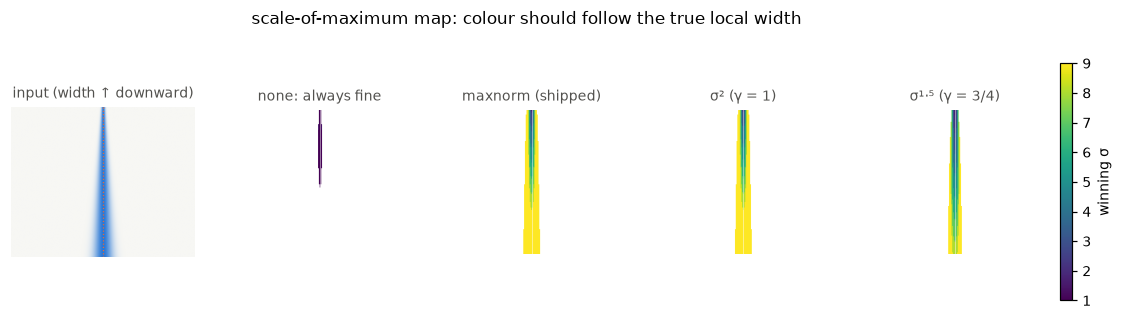

In [19]:
H, W = 180, 220
yy, xx = np.indices((H, W), dtype=float)
# True ridge width grows from ~1.5 px at the top to ~8 px at the bottom.
true_w = 1.5 + 6.5 * (yy / (H - 1))
tapered = np.exp(-((xx - W / 2) ** 2) / (2 * true_w**2))
DENSE = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])


def scale_of_maximum(per_scale, floor_frac=0.15):
    """Winning σ at each pixel; NaN where the fused response is weak."""
    stack = np.stack([per_scale[s] for s in DENSE], axis=0)
    fused = stack.max(0)
    winner = DENSE[stack.argmax(0)]
    winner = winner.astype(float)
    winner[fused < floor_frac * fused.max()] = np.nan
    return winner


fig, axes = plt.subplots(1, 5, figsize=(12.5, 2.8))
bare(axes[0], "input (width ↑ downward)")
axes[0].imshow(tapered, cmap=SEQ)
axes[0].plot([W / 2] * 2, [0, H - 1], color=C_TWO, lw=0.8, ls=":")

titles = {
    "none": "none: always fine",
    "maxnorm": "maxnorm (shipped)",
    "gamma": r"σ² (γ = 1)",
    "lindeberg": r"σ¹·⁵ (γ = 3/4)",
}
for ax, how in zip(axes[1:], ("none", "maxnorm", "gamma", "lindeberg")):
    _, per = meijering_core(tapered, DENSE, how=how, black_ridges=False)
    smap = scale_of_maximum(per)
    im = ax.imshow(smap, cmap="viridis", vmin=1, vmax=9)
    # True width along the centreline, for comparison.
    ax.plot(np.full(H, W / 2), np.arange(H), color="white", lw=0.6, alpha=0.5)
    bare(ax, titles[how])
fig.colorbar(im, ax=axes[1:], fraction=0.02, pad=0.02, label="winning σ")
fig.suptitle("scale-of-maximum map: colour should follow the true local width",
             y=1.05);

What the eye should see: `none` is a flat fine-scale sheet; `maxnorm` can look
plausible on a clean ridge but is free to jump when a far structure changes a
scale's max (next probe); `σ²` tracks the taper but sits systematically coarse;
`σ¹·⁵` tracks the true width most closely.

### 6.2 Unit assertion: two known widths, discrete σ grid

Same construction as §2, tightened for a test. On a dense-enough scan the
winning σ at each ridge centre must land on the grid point nearest the true
width under γ = 3/4, and must *not* under `none` or γ = 1.

In [20]:
def winning_sigma(image, col, sigmas, how):
    _, per = meijering_core(image, sigmas, how=how, black_ridges=False)
    row = image.shape[0] // 2
    return max(sigmas, key=lambda s: per[s][row, col])


def nearest(sigmas, width):
    return min(sigmas, key=lambda s: abs(s - width))


sigmas = (1, 2, 3, 4, 5, 6, 7, 8)
narrow_w, wide_w = 2.0, 6.0
two = (np.exp(-((cols - 60) ** 2) / (2 * narrow_w**2))
       + np.exp(-((cols - 170) ** 2) / (2 * wide_w**2)))

print(f"{'how':<12}{'narrow (want ~2)':>18}{'wide (want ~6)':>16}")
for how in ("none", "maxnorm", "gamma", "lindeberg"):
    print(f"{how:<12}{winning_sigma(two, 60, sigmas, how):>18}"
          f"{winning_sigma(two, 170, sigmas, how):>16}")

# The assertion a PR would carry:
assert winning_sigma(two, 60, sigmas, "lindeberg") == nearest(sigmas, narrow_w)
assert winning_sigma(two, 170, sigmas, "lindeberg") == nearest(sigmas, wide_w)
assert winning_sigma(two, 170, sigmas, "none") == min(sigmas)
assert winning_sigma(two, 170, sigmas, "gamma") > nearest(sigmas, wide_w)
print("assertions passed")

how           narrow (want ~2)  wide (want ~6)


none                         1               1


maxnorm                      1               6


gamma                        3               8


lindeberg                    2               6


assertions passed


Tolerances stay discrete (exact grid match) as long as the true widths sit on
the scan and the ridges are well separated. That avoids brittle float
comparisons on response amplitudes.

### 6.3 Locality: a distant distractor must not retune a ridge

Place the same narrow ridge on the left. Add a bright wide blob in the far
corner that fires strongly at large σ. Under per-scale `/max`, the blob raises
the large-σ maximum and can demote the large-σ contribution relative to fine
scales at the *ridge* — or more simply, change the fused value there. Under
`σ¹·⁵` the ridge response is unchanged.

how           max |Δ| on ridge


maxnorm                 0.3729


lindeberg               0.0000


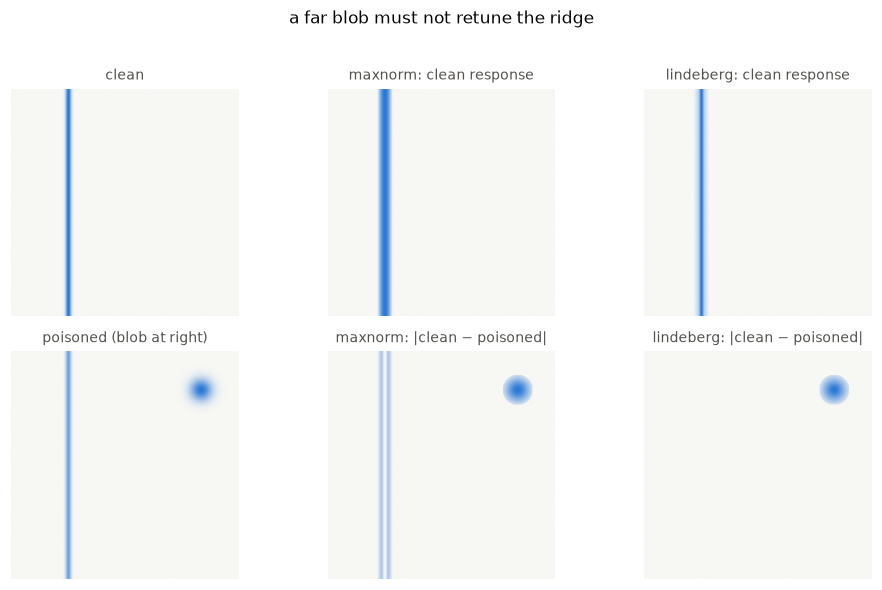

In [21]:
clean = np.exp(-((cols - 60) ** 2) / (2 * 2.0**2))
poisoned = clean.copy()
# Wide bright blob, far from the ridge.
poisoned += 1.5 * np.exp(-(((rows - 40) ** 2) + (cols - 200) ** 2) / (2 * 8.0**2))

fig, axes = plt.subplots(2, 3, figsize=(9.0, 5.2))
bare(axes[0, 0], "clean")
axes[0, 0].imshow(clean, cmap=SEQ)
bare(axes[1, 0], "poisoned (blob at right)")
axes[1, 0].imshow(poisoned, cmap=SEQ)

ridge_slice = (slice(N // 2 - 5, N // 2 + 6), slice(50, 70))
print(f"{'how':<12}{'max |Δ| on ridge':>18}")
for col, how in enumerate(("maxnorm", "lindeberg"), start=1):
    out_c, _ = meijering_core(clean, SCAN, how=how, black_ridges=False)
    out_p, _ = meijering_core(poisoned, SCAN, how=how, black_ridges=False)
    delta = np.abs(out_c - out_p)
    print(f"{how:<12}{delta[ridge_slice].max():>18.4f}")
    bare(axes[0, col], f"{how}: clean response")
    axes[0, col].imshow(out_c, cmap=SEQ)
    bare(axes[1, col], f"{how}: |clean − poisoned|")
    axes[1, col].imshow(delta, cmap=SEQ)
fig.suptitle("a far blob must not retune the ridge", y=1.02)
fig.tight_layout()

For a pytest port: assert `delta[ridge] == 0` (within Hessian border noise) for
`lindeberg`, and assert `delta[ridge] > tol` for today's `maxnorm`. Cropping
the image (already measured in §1) is the same test without a synthetic blob.

### What to put in `test_ridges.py`

Keep the hero figure for the gallery / this notebook. In the unit suite ship
only §6.2 and §6.3 — they are small, deterministic, and name the property under
test (`test_meijering_scale_matches_ridge_width`,
`test_meijering_response_is_local`). Do not assert bit-identity with NeuronJ on
multiscale images: NeuronJ is single-scale.

## 7. What to do

**The defect is real and is worth an issue.** `meijering` is the only ridge
filter in `skimage` whose *comparison between scales* depends on pixels
arbitrarily far away. Cropping an image changes the answer for the part that
remains by 16% on the `camera` photograph; brightening one corner pixel changes
it by 87% a hundred pixels away. Neither is defensible for a filter, and
neither is documented. (`frangi` is non-local too, through its default
`gamma`, but by a single frozen scalar that leaves the scale comparison
intact; see §1 and `on_frangi.md`.) For a *single* sigma the paper's ρ = λ/λ_min is the same global
rescale everywhere, so relative structure inside one scale is unchanged; the
harm appears when each scale divides by a *different* max before the
cross-scale maximum.

**Paper vs skimage.** Faithful single-scale Meijering: keep ρ ∝ λ/λ_min (or
document an optional final normalize), use α = −1/(ndim+1) as the docstring
already claims and as the flatness criterion requires (α = −1/3 in 2-D). The
code today sets `alpha = +1/(ndim+1)` — opposite sign to the paper and to its
own docstring. No per-scale σ power is required when `sigmas` has one entry.

**Optimum for skimage's multiscale API.** The paper does not define max-over-
sigmas. For that extension, prefer local γ-normalisation, then max, then at
most one global normalize on the fused map:

1. Multiply the (clipped) neuriteness at each scale by `sigma**(2 * gamma)`
   with **`gamma = 3/4` → `sigma**1.5`**.
2. Take the pixel-wise maximum across scales **without** per-scale `/max`.
3. Optionally divide the result by its global max once, if a [0, 1] map is
   wanted for display or costs (paper ρ, applied after fusion).

Why 3/4 rather than 1. Section 5: for a Gaussian ridge, Lindeberg's
γ-normalised principal-curvature strength peaks at the true width only when
γ = 3/4. With γ = 1 the continuous model peaks at σ\* = w√2, and the discrete
scan in §4 prefers `sigma**1.5` (picks 2 and 6) over `sigma**2` (picks 2 and
8). Sato already uses `sigma**2` on its vesselness product; that is a
reasonable family convention, but for *this* filter's scale selection it is
second-best.

**Do not** equate "#5561: no σ² in the paper" with "keep nonlocal `/max` under
multiscale." Those answer different questions: display mapping versus fair
comparison of scales.

**Relation to fixes A and C.** They are independent and both are needed. A and C
correct the Hessian this filter consumes; nothing in them touches the
normalisation, which is why `meijering` alone keeps a residue after they land.
Conversely a normalisation fix does not repair the border. The one place they
meet is `truncate = 100`, and its origin is the same thread as this defect:
in #5561 the reporter concluded that the accuracy gain he had been chasing "is
just down to the use of the large truncation value of 100", and that it is
"relevant to use a (much) larger truncation value once sigma values become
small". `on_hessian.md` Fix C shows that a corrected kernel needs no such
margin, so fixing the kernel retires the hack that this thread introduced.

Measured with scikit-image from this working tree, on the 256x256 `camera`
photograph and a 240x240 synthetic pair of ridges.

In [22]:
print(f"scikit-image {ski.__version__}")

scikit-image 0.26.1rc0.dev0+git20260909.b6e9c5ce5
